In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

CAP_GQL = "https://celltype.info/graphql"

DATASETS = {
    "epithelial": "2166",
    "myeloid": "2167",
    "stromal": "2168",
    "lymphoid": "2169",
}

In [11]:
### Style setup

import matplotlib as mpl

NATURE_PALETTE = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
]


def set_nature_style(font_size_pt=6):
    mpl.rcParams.update({
        "font.family": "Helvetica",
        "font.size": font_size_pt,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.titlecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.edgecolor": "black",
        "savefig.format": "pdf",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "legend.frameon": False,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
    })

def mm_to_in(mm):
    return mm / 25.4

def figure_nature(width_mm=89, height_mm=60, font_size_pt=6):
    set_nature_style(font_size_pt=font_size_pt)
    fig, ax = plt.subplots(figsize=(mm_to_in(width_mm), mm_to_in(height_mm)))
    return fig, ax

def save_pdf(fig, path):
    fig.savefig(path, bbox_inches="tight", transparent=True)


## Quantify unique comments and votes

In [2]:
QUERY = """
query DatasetFeedbackCounts($datasetId: ID!) {
  dataset(datasetId: $datasetId) {
    id
    name
    labelsets {
      id
      name
      mode
      labels {
        id
        name
        scores {
          agree
          disagree
          idk
        }
        feedbacks {
          createdAt
          user {
            uid
            displayName
          }
          score
          explanation {
            type
            data {
              ... on FeedbackExplanationDataComment { comment }
              ... on FeedbackExplanationDataMerge { comment }
              ... on FeedbackExplanationDataSplit { comment }
              ... on FeedbackExplanationDataRefine { changes { attribute originalValue newValue } }
            }
          }
        }
      }
    }
  }
}
"""


In [3]:
def gql(query, variables):
    r = requests.post(CAP_GQL, json={"query": query, "variables": variables}, timeout=180)
    r.raise_for_status()
    j = r.json()
    if "errors" in j:
        raise RuntimeError(j["errors"])
    return j["data"]

def is_comment(feedback):
    exp = feedback.get("explanation") or {}
    data = exp.get("data") or {}
    c = data.get("comment")
    if c is None:
        return False
    if isinstance(c, str) and c.strip() == "":
        return False
    return True

rows = []
events = []



In [4]:
for lineage, dsid in DATASETS.items():
    data = gql(QUERY, {"datasetId": dsid})
    ds = data["dataset"]
    total_votes = 0
    unique_voters = set()
    total_comments = 0
    unique_commenters = set()
    for labelset in ds["labelsets"]:
        for label in labelset["labels"]:
            sc = label.get("scores") or {}
            total_votes += int(sc.get("agree") or 0) + int(sc.get("disagree") or 0) + int(sc.get("idk") or 0)
            for fb in (label.get("feedbacks") or []):
                uid = (fb.get("user") or {}).get("uid")
                if uid:
                    unique_voters.add(uid)
                if is_comment(fb):
                    total_comments += 1
                    if uid:
                        unique_commenters.add(uid)
                created = fb.get("createdAt")
                if created and uid:
                    events.append({
                        "lineage": lineage,
                        "dataset_id": dsid,
                        "dataset_name": ds.get("name"),
                        "createdAt": created,
                        "uid": uid,
                        "is_comment": is_comment(fb),
                    })
    rows.append({
        "lineage": lineage,
        "dataset_id": dsid,
        "dataset_name": ds.get("name"),
        "unique_voters": len(unique_voters),
        "total_votes": total_votes,
        "unique_commenters": len(unique_commenters),
        "total_comments": total_comments,
    })

summary = pd.DataFrame(rows).sort_values("lineage")
print(summary)

      lineage dataset_id                              dataset_name  \
0  epithelial       2166  HCA Gut Cell Atlas v1 Epithelial Lineage   
3    lymphoid       2169    HCA Gut Cell Atlas v1 Lymphoid Lineage   
1     myeloid       2167     HCA Gut Cell Atlas v1 Myeloid Lineage   
2     stromal       2168     HCA Gut Cell Atlas v1 Stromal Lineage   

   unique_voters  total_votes  unique_commenters  total_comments  
0             10           96                 10              88  
3              7           58                  7              58  
1              7           24                  7              24  
2              6           56                  6              55  


In [15]:
def reorder_lineages(df):
    order = ["epithelial", "stromal", "lymphoid", "myeloid"]
    cols = [c for c in df.columns if c != "lineage"]
    df = df.copy()
    df["lineage"] = pd.Categorical(df["lineage"], categories=order, ordered=True)
    return df.sort_values("lineage")[["lineage"] + cols]

summary = reorder_lineages(summary)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


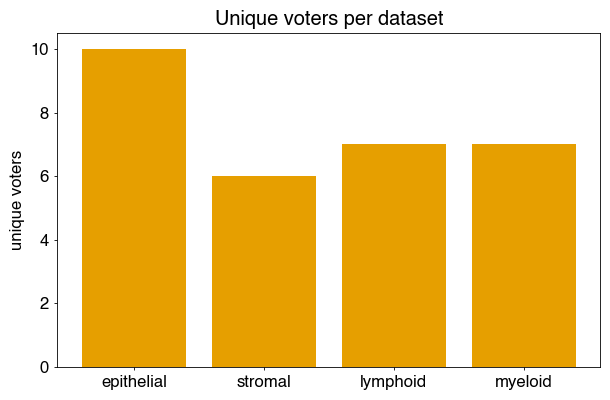

In [23]:
fig, ax = figure_nature(width_mm=178, height_mm=110, font_size_pt=12)
ax.bar(summary["lineage"], summary["unique_voters"], color=NATURE_PALETTE[0])
ax.set_title("Unique voters per dataset")
ax.set_ylabel("unique voters")
ax.set_xlabel("")
save_pdf(fig, "/Users/kylekimler/Projects/GCA/github_vignette_output/CAP_metrics/cap_fig1_unique_voters_per_dataset.pdf")
plt.show()

plt.close(fig)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


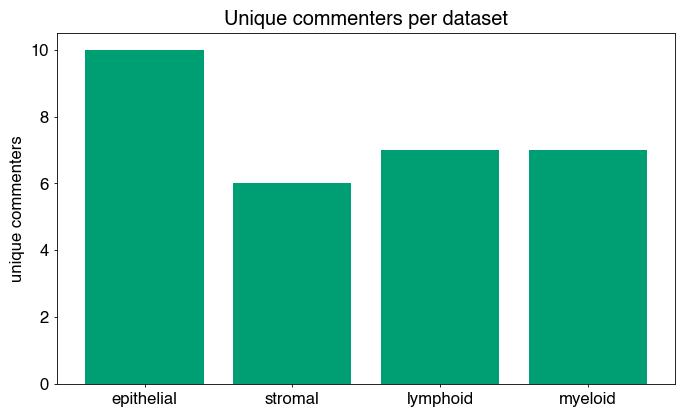

In [22]:
fig, ax = figure_nature(width_mm=178, height_mm=110, font_size_pt=12)
ax.bar(summary["lineage"], summary["unique_commenters"], color=NATURE_PALETTE[2])
ax.set_title("Unique commenters per dataset")
ax.set_ylabel("unique commenters")
ax.set_xlabel("")
plt.tight_layout()
save_pdf(fig, "/Users/kylekimler/Projects/GCA/github_vignette_output/CAP_metrics/cap_fig1_unique_commenters_per_dataset.pdf")
plt.show()



In [7]:
ev = pd.DataFrame(events)
ev["createdAt"] = pd.to_datetime(ev["createdAt"], utc=True)
ev["date"] = ev["createdAt"].dt.date

def cumulative_unique(df, col):
    df = df.sort_values("date")
    seen = set()
    out = []
    for d, g in df.groupby("date"):
        for x in g[col].tolist():
            seen.add(x)
        out.append({"date": d, "cumulative_unique": len(seen)})
    return pd.DataFrame(out)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


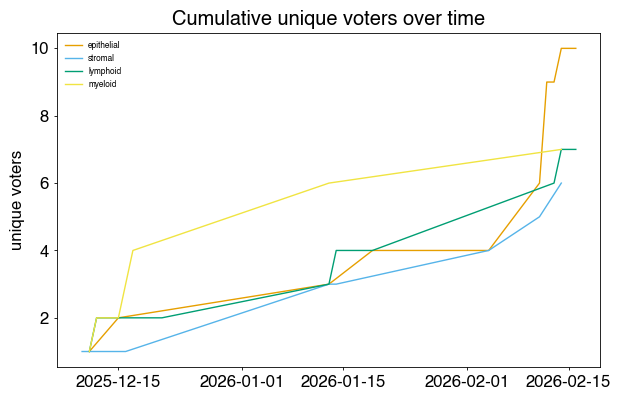

In [29]:
fig, ax = figure_nature(width_mm=178, height_mm=110, font_size_pt=12)
for i, lineage in enumerate([x for x in summary["lineage"].tolist()]):
    sub = ev[ev["lineage"] == lineage]
    if len(sub) == 0:
        continue
    cu = cumulative_unique(sub, "uid")
    ax.plot(
        pd.to_datetime(cu["date"]),
        cu["cumulative_unique"],
        label=lineage,
        color=NATURE_PALETTE[i % len(NATURE_PALETTE)],
        linewidth=1.0,
    )
ax.set_title("Cumulative unique voters over time")
ax.set_ylabel("unique voters")
ax.legend(fontsize=6)
save_pdf(fig, "/Users/kylekimler/Projects/GCA/github_vignette_output/CAP_metrics/cap_fig3_cumulative_unique_voters_over_time.pdf")
plt.show()
plt.close(fig)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


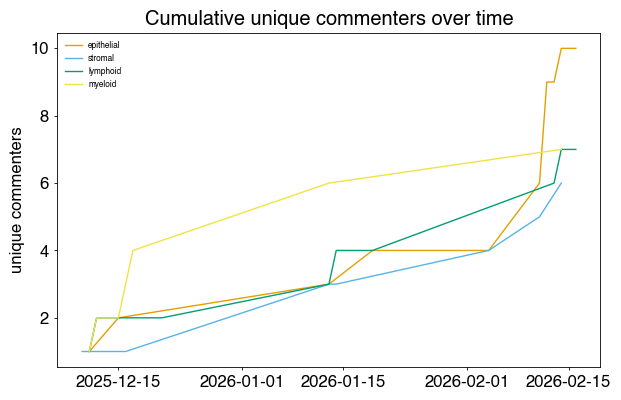

In [30]:
fig, ax = figure_nature(width_mm=178, height_mm=110, font_size_pt=12)
for i, lineage in enumerate([x for x in summary["lineage"].tolist()]):
    sub = ev[(ev["lineage"] == lineage) & (ev["is_comment"])]
    if len(sub) == 0:
        continue
    cu = cumulative_unique(sub, "uid")
    ax.plot(
        pd.to_datetime(cu["date"]),
        cu["cumulative_unique"],
        label=lineage,
        color=NATURE_PALETTE[i % len(NATURE_PALETTE)],
        linewidth=1.0,
    )
ax.set_title("Cumulative unique commenters over time")
ax.set_ylabel("unique commenters")
ax.legend(fontsize=6)
save_pdf(fig, "/Users/kylekimler/Projects/GCA/github_vignette_output/CAP_metrics/cap_fig4_cumulative_unique_commenters_over_time.pdf")
plt.show()
plt.close(fig)

## Quantify comments per cell type

In [31]:
lineage_colors = {
    "epithelial": NATURE_PALETTE[0],
    "myeloid": NATURE_PALETTE[1],
    "stromal": NATURE_PALETTE[2],
    "lymphoid": NATURE_PALETTE[4],
}

label_rows = []

for lineage, dsid in DATASETS.items():
    data = gql(QUERY, {"datasetId": dsid})
    ds = data["dataset"]

    for labelset in ds["labelsets"]:
        for label in labelset["labels"]:
            sc = label.get("scores") or {}
            agree = int(sc.get("agree") or 0)
            disagree = int(sc.get("disagree") or 0)
            idk = int(sc.get("idk") or 0)
            total = agree + disagree + idk

            label_rows.append({
                "lineage": lineage,
                "dataset_id": dsid,
                "dataset_name": ds.get("name"),
                "labelset_name": labelset.get("name"),
                "label_id": label.get("id"),
                "cell_type": label.get("name"),
                "agree": agree,
                "disagree": disagree,
                "idk": idk,
                "total": total,
                "net": agree - disagree,
                "disagree_frac": (disagree / total) if total > 0 else np.nan,
            })

labels = pd.DataFrame(label_rows)

labels = labels[labels["total"] > 0].copy()


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


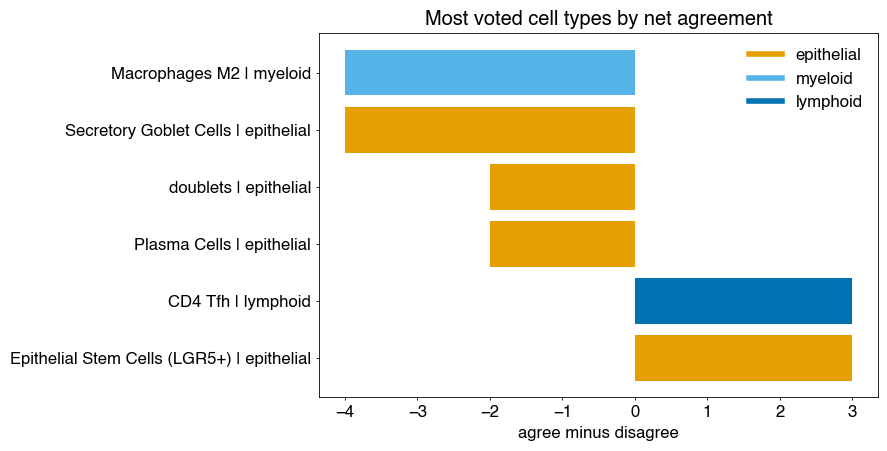

In [36]:
def plot_ranked_barh(df, value_col, title, xlabel, out_pdf, n=20, width_mm=183, height_mm=120):
    df = df.sort_values(value_col, ascending=False).head(n).copy()
    df["label"] = (
        df["cell_type"].astype(str)
        + " | "
        + df["lineage"].astype(str)
    )
    fig, ax = figure_nature(width_mm=width_mm, height_mm=height_mm, font_size_pt=12)
    y = np.arange(len(df))[::-1]
    vals = df[value_col].to_numpy()[::-1]
    colors = [lineage_colors.get(x, "black") for x in df["lineage"].to_list()][::-1]
    ax.barh(y, vals, color=colors)
    ax.set_yticks(y)
    ax.set_yticklabels(df["label"].to_list()[::-1])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    handles = []
    for lin in ["epithelial", "myeloid", "stromal", "lymphoid"]:
        if lin in set(df["lineage"].tolist()):
            handles.append(plt.Line2D([0], [0], color=lineage_colors[lin], lw=4, label=lin))
    if len(handles) > 0:
        ax.legend(handles=handles, fontsize=12)
    save_pdf(fig, out_pdf)
    plt.show()
    plt.close(fig)

min_total = 5
labels_filt = labels[labels["total"] >= min_total].copy()

plot_ranked_barh(
    labels_filt,
    value_col="net",
    title="Most voted cell types by net agreement",
    xlabel="agree minus disagree",
    out_pdf="/Users/kylekimler/Projects/GCA/github_vignette_output/CAP_metrics/cap_rank_net_upvoted.pdf",
    n=20,
)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


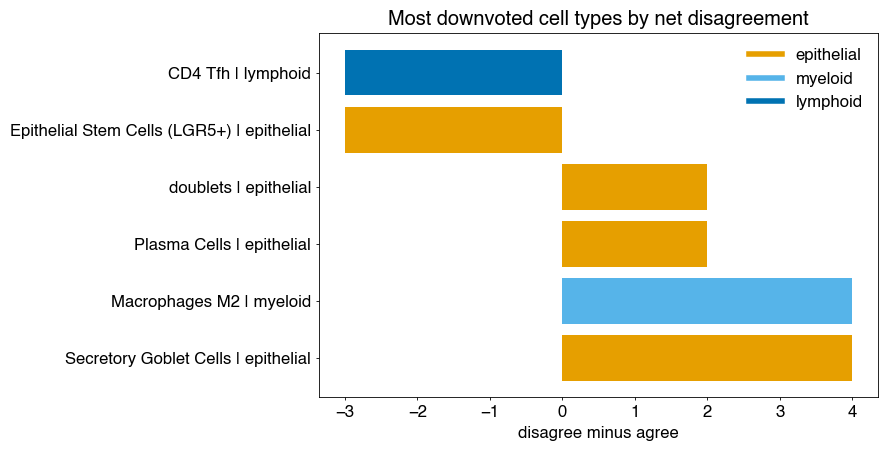

In [37]:

labels_filt["net_down"] = -(labels_filt["net"])
plot_ranked_barh(
    labels_filt,
    value_col="net_down",
    title="Most downvoted cell types by net disagreement",
    xlabel="disagree minus agree",
    out_pdf="/Users/kylekimler/Projects/GCA/github_vignette_output/CAP_metrics/cap_rank_net_downvoted.pdf",
    n=20,
)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


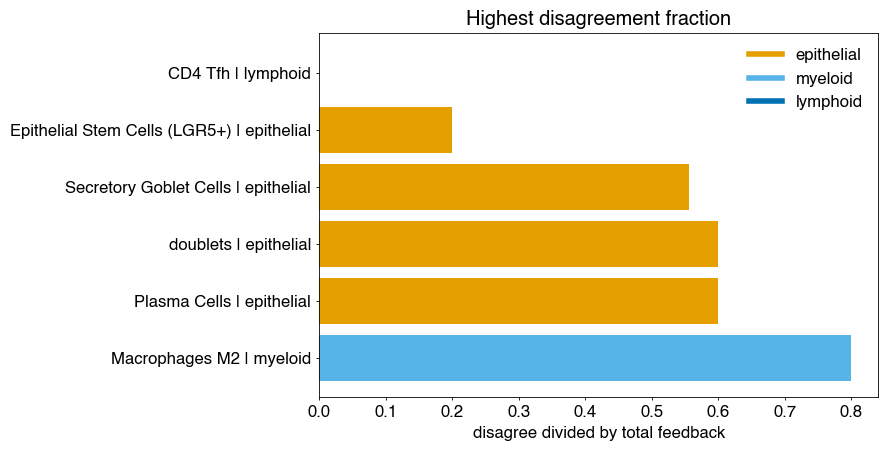

In [38]:

plot_ranked_barh(
    labels_filt,
    value_col="disagree_frac",
    title="Highest disagreement fraction",
    xlabel="disagree divided by total feedback",
    out_pdf="/Users/kylekimler/Projects/GCA/github_vignette_output/CAP_metrics/cap_rank_disagree_fraction.pdf",
    n=20,
)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


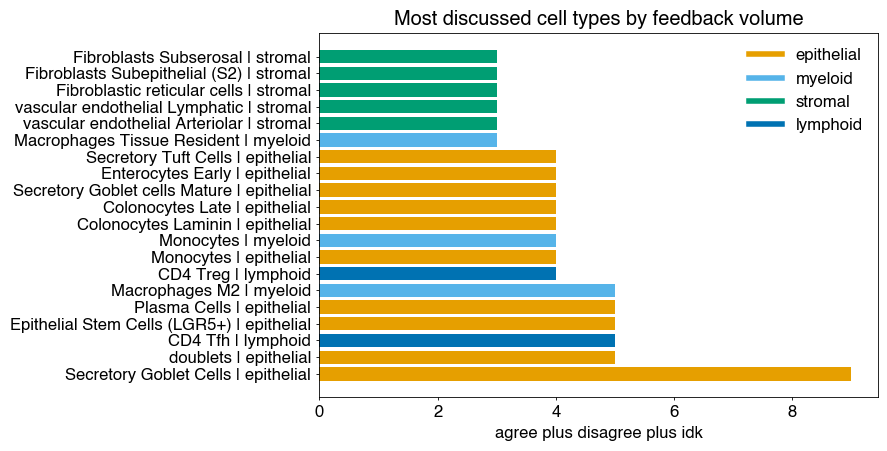

         lineage                      cell_type  agree  disagree  idk  total  \
10    epithelial         Secretory Goblet Cells      1         5    3      9   
7     epithelial                       doublets      1         3    1      5   
1510    lymphoid                        CD4 Tfh      3         0    2      5   
0     epithelial  Epithelial Stem Cells (LGR5+)      4         1    0      5   
3     epithelial                   Plasma Cells      1         3    1      5   
794      myeloid                 Macrophages M2      0         4    1      5   
1513    lymphoid                       CD4 Treg      3         0    1      4   
5     epithelial                      Monocytes      0         4    0      4   
796      myeloid                      Monocytes      1         2    1      4   
11    epithelial            Colonocytes Laminin      2         1    1      4   

      net  disagree_frac  
10     -4       0.555556  
7      -2       0.600000  
1510    3       0.000000  
0       3  

In [40]:

plot_ranked_barh(
    labels,
    value_col="total",
    title="Most discussed cell types by feedback volume",
    xlabel="agree plus disagree plus idk",
    out_pdf="/Users/kylekimler/Projects/GCA/github_vignette_output/CAP_metrics/cap_rank_total_feedback.pdf",
    n=20,
)

print(labels.sort_values("total", ascending=False).head(10)[
    ["lineage", "cell_type", "agree", "disagree", "idk", "total", "net", "disagree_frac"]
])

## Save summary csv

In [41]:
import requests
import pandas as pd

CAP_GQL = "https://celltype.info/graphql"

DATASETS = {
    "epithelial": "2166",
    "myeloid": "2167",
    "stromal": "2168",
    "lymphoid": "2169",
}

QUERY = """
query DatasetFeedbackCounts($datasetId: ID!) {
  dataset(datasetId: $datasetId) {
    id
    name
    labelsets {
      id
      name
      mode
      labels {
        id
        name
        scores {
          agree
          disagree
          idk
        }
        feedbacks {
          createdAt
          user {
            uid
            displayName
          }
          score
          explanation {
            type
            data {
              ... on FeedbackExplanationDataComment { comment }
              ... on FeedbackExplanationDataMerge { comment }
              ... on FeedbackExplanationDataSplit { comment }
              ... on FeedbackExplanationDataRefine { changes { attribute originalValue newValue } }
            }
          }
        }
      }
    }
  }
}
"""

def gql(query, variables):
    r = requests.post(CAP_GQL, json={"query": query, "variables": variables}, timeout=180)
    r.raise_for_status()
    j = r.json()
    if "errors" in j:
        raise RuntimeError(j["errors"])
    return j["data"]

def extract_comment(feedback):
    exp = feedback.get("explanation") or {}
    data = exp.get("data") or {}
    c = data.get("comment")
    if c is None:
        return None
    if isinstance(c, str):
        t = c.strip()
        if t == "":
            return None
        return t
    return None


In [43]:

label_rows = []
comment_rows = []

for lineage, dsid in DATASETS.items():
    data = gql(QUERY, {"datasetId": dsid})
    ds = data["dataset"]
    for labelset in ds["labelsets"]:
        for label in labelset["labels"]:
            sc = label.get("scores") or {}
            agree = int(sc.get("agree") or 0)
            disagree = int(sc.get("disagree") or 0)
            idk = int(sc.get("idk") or 0)
            voters = set()
            commenters = set()
            n_comments = 0
            for fb in (label.get("feedbacks") or []):
                user = fb.get("user") or {}
                uid = user.get("uid")
                if uid:
                    voters.add(uid)
                c = extract_comment(fb)
                if c is not None:
                    n_comments += 1
                    if uid:
                        commenters.add(uid)
                    comment_rows.append({
                        "lineage": lineage,
                        "dataset_id": dsid,
                        "dataset_name": ds.get("name"),
                        "labelset_name": labelset.get("name"),
                        "label_id": label.get("id"),
                        "annotation": label.get("name"),
                        "createdAt": fb.get("createdAt"),
                        "user_uid": uid,
                        "user_displayName": user.get("displayName"),
                        "score": fb.get("score"),
                        "explanation_type": (fb.get("explanation") or {}).get("type"),
                        "comment": c,
                    })
            label_rows.append({
                "lineage": lineage,
                "dataset_id": dsid,
                "dataset_name": ds.get("name"),
                "labelset_name": labelset.get("name"),
                "label_id": label.get("id"),
                "annotation": label.get("name"),
                "agree": agree,
                "disagree": disagree,
                "idk": idk,
                "total_votes": agree + disagree + idk,
                "unique_voters": len(voters),
                "n_comments": n_comments,
                "unique_commenters": len(commenters),
            })


In [44]:

labels = pd.DataFrame(label_rows)
comments_long = pd.DataFrame(comment_rows)

summary = (
    labels
    .groupby(["lineage", "annotation"], dropna=False, as_index=False)
    .agg({
        "agree": "sum",
        "disagree": "sum",
        "idk": "sum",
        "total_votes": "sum",
        "unique_voters": "sum",
        "n_comments": "sum",
        "unique_commenters": "sum",
    })
)

summary["net"] = summary["agree"] - summary["disagree"]

def join_comments(g):
    parts = []
    for _, r in g.sort_values("createdAt").iterrows():
        who = r["user_displayName"] if pd.notna(r["user_displayName"]) else (r["user_uid"] if pd.notna(r["user_uid"]) else "unknown")
        parts.append(f"{r['createdAt']} | {who}: {r['comment']}")
    return "\n".join(parts)

if len(comments_long) > 0:
    comments_blob = (
        comments_long
        .groupby(["lineage", "annotation"], dropna=False)
        .apply(join_comments)
        .reset_index(name="comments_concat")
    )
    summary = summary.merge(comments_blob, on=["lineage", "annotation"], how="left")
else:
    summary["comments_concat"] = ""

summary = summary.sort_values(["lineage", "total_votes"], ascending=[True, False])

summary.to_csv("/Users/kylekimler/Projects/GCA/github_vignette_output/CAP_metrics/cap_annotation_summary.csv", index=False)
comments_long.to_csv("/Users/kylekimler/Projects/GCA/github_vignette_output/CAP_metrics/cap_comments_long.csv", index=False)

print("Wrote cap_annotation_summary.csv and cap_comments_long.csv")
print(summary.head(10))


Wrote cap_annotation_summary.csv and cap_comments_long.csv
        lineage                     annotation  agree  disagree  idk  \
701  epithelial         Secretory Goblet Cells      1         5    3   
361  epithelial  Epithelial Stem Cells (LGR5+)      4         1    0   
698  epithelial                   Plasma Cells      1         3    1   
741  epithelial                       doublets      1         3    1   
321  epithelial            Colonocytes Laminin      2         1    1   
322  epithelial               Colonocytes Late      3         0    1   
349  epithelial              Enterocytes Early      1         2    1   
684  epithelial                      Monocytes      0         4    0   
702  epithelial  Secretory Goblet cells Mature      1         3    0   
705  epithelial           Secretory Tuft Cells      3         1    0   

     total_votes  unique_voters  n_comments  unique_commenters  net  \
701            9              9           9                  9   -4   
361   

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_52911/1890079174.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(join_comments)


## Total comments

In [46]:
def lineage_agg_from_summary(summary_df):
    df = summary_df.copy()
    agg = (
        df.groupby("lineage", as_index=False)
        .agg({
            "n_comments": "sum",
            "unique_commenters": "sum",
        })
    )
    agg["comments_per_unique_commenter"] = agg["n_comments"] / agg["unique_commenters"].replace(0, np.nan)
    order = ["epithelial", "myeloid", "stromal", "lymphoid"]
    agg["lineage"] = pd.Categorical(agg["lineage"], categories=order, ordered=True)
    return agg.sort_values("lineage")

lineage_counts = lineage_agg_from_summary(summary)



1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


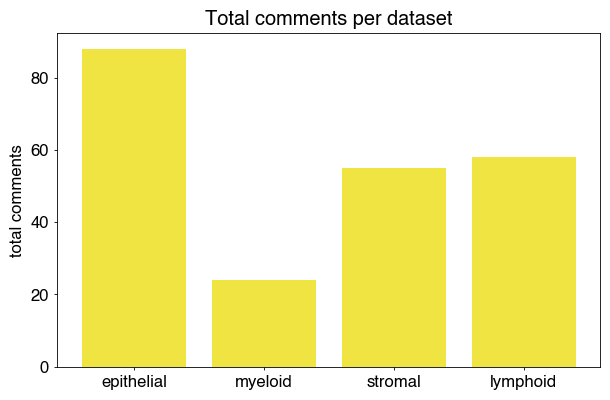

In [49]:
fig, ax = figure_nature(width_mm=178, height_mm=110, font_size_pt=12)
ax.bar(lineage_counts["lineage"], lineage_counts["n_comments"], color=NATURE_PALETTE[3])
ax.set_title("Total comments per dataset")
ax.set_ylabel("total comments")
ax.set_xlabel("")
save_pdf(fig, "/Users/kylekimler/Projects/GCA/github_vignette_output/CAP_metrics/cap_fig5_total_comments_per_lineage.pdf")
plt.show()
plt.close(fig)


In [52]:
def lineage_comment_metrics(comments_long_df):
    df = comments_long_df.copy()
    df["user_uid"] = df["user_uid"].fillna("")
    has_uid = df["user_uid"] != ""
    agg = (
        df.groupby("lineage", as_index=False)
        .agg(
            total_comments=("comment", "count"),
            unique_commenters=("user_uid", lambda s: s[s != ""].nunique()),
        )
    )
    agg["comments_per_unique_commenter"] = (
        agg["total_comments"] / agg["unique_commenters"].replace(0, np.nan)
    )
    order = ["epithelial", "myeloid", "stromal", "lymphoid"]
    agg["lineage"] = pd.Categorical(agg["lineage"], categories=order, ordered=True)
    return agg.sort_values("lineage")

lineage_counts = lineage_comment_metrics(comments_long)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


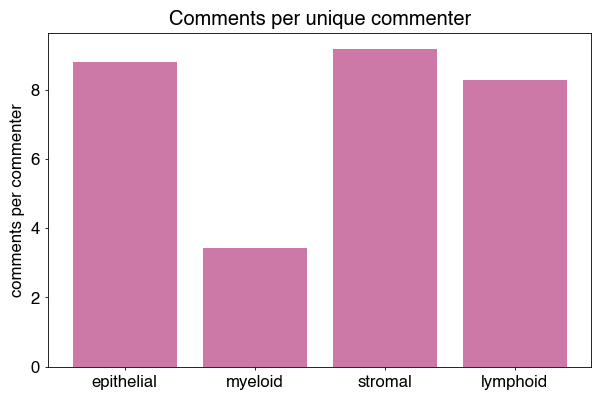

In [53]:
fig, ax = figure_nature(width_mm=178, height_mm=110, font_size_pt=12)
ax.bar(lineage_counts["lineage"], lineage_counts["comments_per_unique_commenter"], color=NATURE_PALETTE[6])
ax.set_title("Comments per unique commenter")
ax.set_ylabel("comments per commenter")
ax.set_xlabel("")
save_pdf(fig, "/Users/kylekimler/Projects/GCA/github_vignette_output/CAP_metrics/cap_fig6_comments_per_unique_commenter_per_lineage.pdf")
plt.show()
plt.close(fig)
